<a href="https://colab.research.google.com/github/Vermont-Complex-Systems/storywrangler/blob/main/notebooks/getting_started_sdk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting started with Storywrangler SDK

In this notebook, we show how to access the Storywrangler registry and explore available datasets using the SDK.

In [ ]:
!pip install -U storywrangler

In [2]:
# local packages
from storywrangler import Storywrangler

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
import storywrangler
print(storywrangler.__version__)

0.0.21


In [4]:
client=Storywrangler()

## Exploring datasets

In [5]:
r = client.registry

In [6]:
# displaying a client shows what its route serves — here, the catalog itself
r

Registry — 21 datasets:
  babynames/ngrams                     latest   Baby names by popularity, year, and location with entity ...
  bluesky/ngrams                       latest   Date-first ngram distributions for Bluesky — all count me...
  bluesky/ngrams-sparklines            latest   Precomputed per-term time series for bluesky/ngrams — all...
  open-academic-analytics/academic-research-groups latest   UVM faculty roster with OpenAlex IDs, departments, and re...
  open-academic-analytics/authors      latest   Per-author summary: current career age, last publication ...
  open-academic-analytics/coauthors    latest   UVM faculty coauthor relationships with age categories an...
  open-academic-analytics/papers       latest   UVM faculty papers with UMAP embeddings, citation metrics...
  open-academic-analytics/training     latest   UVM faculty collaboration training data in wide format wi...
  reddit/ngrams                        latest   Reddit ngrams
  reddit/ngrams-sparklines    

In [7]:
# when applicable, dataframe is callable
r.list().df().head()

,catalog,domain,dataset_id,version,data_location,data_format,description,endpoint_schema,lineage,level_order,filter_values,created_at,updated_at
0,vcsi,babynames,ngrams,latest,[/users/j/s/jstonge1/babynames/metadata.duckla...,parquet,"Baby names by popularity, year, and location w...","{'type': 'types-counts', 'type_column': None, ...",{'sources': {'geo': {'quebec': ['https://www.d...,None,"{'sex': ['F', 'M']}",2026-04-07T16:35:14.417279+00:00,2026-07-17T15:03:23.490632+00:00
1,vcsi,bluesky,ngrams,latest,/netfiles/wikimedia_snapshots/bluesky_agg/dist,parquet_hive,Date-first ngram distributions for Bluesky — a...,"{'type': 'types-counts', 'type_column': 'ngram...","{'sources': None, 'derived_from': None, 'consu...","[{'column': 'n', 'type': 'filter', 'default_va...","{'n': [1, 2], 'lang': ['af', 'als', 'am', 'an'...",2026-07-22T18:35:56.002653+00:00,2026-07-25T12:41:05.338621+00:00
2,vcsi,bluesky,ngrams-sparklines,latest,/netfiles/wikimedia_snapshots/bluesky_agg/spar...,parquet_hive,Precomputed per-term time series for bluesky/n...,"{'type': 'types-counts', 'type_column': 'ngram...","{'sources': None, 'derived_from': ['bluesky/ng...","[{'column': 'n', 'type': 'partition', 'default...","{'n': [1, 2], 'lang': ['af', 'als', 'am', 'an'...",2026-07-23T18:07:45.149931+00:00,2026-07-25T12:41:10.951518+00:00
3,vcsi,open-academic-analytics,academic-research-groups,latest,/users/j/s/jstonge1/academic-research-groups/a...,parquet,"UVM faculty roster with OpenAlex IDs, departme...",None,{'sources': {'payroll': {'FY2023': 'https://uv...,None,None,2026-04-07T16:50:31.443578+00:00,2026-04-20T17:47:35.246812+00:00
4,vcsi,open-academic-analytics,authors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"Per-author summary: current career age, last p...",None,"{'sources': None, 'derived_from': ['open-acade...",None,None,2026-04-07T16:47:46.316179+00:00,2026-04-07T16:47:46.320173+00:00


- Note that we use 3-level naming to identify dataset: `catalog/domain/dataset_id`
- The storywrangler `sdk` is designed to match the [api-reference](https://storywrangler.uvm.edu/api-reference), e.g. [https://api.storywrangler.uvm.edu/registry/](https://storywrangler.uvm.edu/api-reference/registry/) -> `client.registry.list()`.
- You get the metadata for each dataset; see [here](https://storywrangler.uvm.edu/api-reference/registry/post-registry-register) for description of all the fields (also we maintain [storywrangler specification](https://storywrangler.uvm.edu/specification#37-dataset-registration-schema), an open source specs to discuss the schema).
- (WIP) The docs are meant to be LLM-friendly as we publish them as [mcp-server](https://github.com/Vermont-Complex-Systems/storywrangler/tree/wiki-hedo/packages/mcp-server), together with a set of agent [skills](https://github.com/Vermont-Complex-Systems/storywrangler/tree/wiki-hedo/.claude/skills).

## Deep dive `wikimedia/ngrams` dataset

In [8]:
# create a dataset object
wiki = client.dataset("wikimedia", "ngrams")
# raw metadata also works: client.registry.get("wikimedia", "ngrams")

In [12]:
wiki.summary.df()

,dimension,kind,default,values,min,max
0,country,entity,None,entity IDs — resolve via .adapter,None,None
1,date,time,None,dates: range,2024-09-01,2026-07-18
2,ngram_size,filter,1,"1, 2",None,None
3,granularity,filter,daily,"daily, monthly, weekly",None,None


In [14]:
# looking up registered transforms
wiki.meta['transform']

{'time_dimension': 'date',
 'filter_dimensions': None,
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [16]:
# lookuping filter values
wiki.meta['filter_values']['ngram_size']

[1, 2]

In [17]:
# entity -> entity local_id as dataframe
wiki.adapter.df()

,local_id,entity_id,entity_name,entity_ids
0,United States,wikidata:Q30,United States,"[iso:US, local:wikimedia:united_states]"
1,United Kingdom,wikidata:Q145,United Kingdom,"[iso:GB, local:wikimedia:united_kingdom]"
2,Canada,wikidata:Q16,Canada,"[iso:CA, local:wikimedia:canada]"
3,Australia,wikidata:Q408,Australia,"[iso:AU, local:wikimedia:australia]"
4,Philippines,wikidata:Q928,Philippines,"[iso:PH, local:wikimedia:philippines]"
5,Bulgaria,wikidata:Q219,Bulgaria,"[iso:BG, local:wikimedia:bulgaria]"
6,Romania,wikidata:Q218,Romania,"[iso:RO, local:wikimedia:romania]"
7,Norway,wikidata:Q20,Norway,"[iso:NO, local:wikimedia:norway]"
8,Finland,wikidata:Q33,Finland,"[iso:FI, local:wikimedia:finland]"
9,India,wikidata:Q668,India,"[iso:IN, local:wikimedia:india]"


In [18]:
# the manifest, or what metadata is available per country
# useful to specify query by filter.
wiki.availability['United States']

{'1': {'daily': {'min': '2024-09-30', 'max': '2026-07-18', 'types': 2481266},
  'monthly': {'min': '2024-09-01', 'max': '2026-07-01', 'types': 3153681},
  'weekly': {'min': '2024-09-30', 'max': '2026-07-13', 'types': 2845447}},
 '2': {'daily': {'min': '2024-09-30', 'max': '2026-07-18', 'types': 15296614},
  'monthly': {'min': '2024-09-01', 'max': '2026-07-01', 'types': 17624583},
  'weekly': {'min': '2024-09-30', 'max': '2026-07-13', 'types': 16608559}}}

Here we show how to use generic query endpoints. The key benefit of those endpoints is that if you follow the contact when registering, they are available out of the box. For instance, the [top-ngrams](https://storywrangler.uvm.edu/api-reference/storywrangler/get-storywrangler-top-ngrams) endpoint works out of the box for datasets registered as `types-counts` endpoint

In [19]:
wiki.meta['endpoint_schema']

{'type': 'types-counts',
 'type_column': 'ngram',
 'count_column': 'pv_count',
 'rank_column': 'pv_rank',
 'freq_column': 'pv_freq',
 'orientation': None,
 'role': None,
 'doc_column': None,
 'score_column': None,
 'order_column': None}

In [20]:
reddit=client.dataset("reddit", "ngrams")

In [ ]:
# ?bb.top_ngrams # inspect docs

In [21]:
# With entity, we can use either local_id or entity_id
# .df() also available here.
wiki.top_ngrams(
    entity="wikidata:Q30",
    dates="2025-01-01", dates2="2025-01-10",
    limit=10
)
# equivalent to
# client.instrument.top_ngrams(
#    "wikimedia", "ngrams", entity="wikidata:Q30", dates="2025-01-01"
#)

{'2025-01-01': [{'types': ',', 'counts': 15859237857},
  {'types': 'the', 'counts': 13066636591},
  {'types': '.', 'counts': 11014987742},
  {'types': 'of', 'counts': 6753426310},
  {'types': 'and', 'counts': 6678340525},
  {'types': 'in', 'counts': 5329998578},
  {'types': 'to', 'counts': 4757284861},
  {'types': '"', 'counts': 4550215820},
  {'types': 'a', 'counts': 4491557031},
  {'types': ')', 'counts': 3085662873}],
 '2025-01-10': [{'types': ',', 'counts': 15086812268},
  {'types': 'the', 'counts': 12851700322},
  {'types': '.', 'counts': 10774969535},
  {'types': 'of', 'counts': 6705015413},
  {'types': 'and', 'counts': 6466306577},
  {'types': 'in', 'counts': 5159175331},
  {'types': 'to', 'counts': 4780958540},
  {'types': 'a', 'counts': 4326957819},
  {'types': '"', 'counts': 3924594214},
  {'types': ')', 'counts': 2975922726}],
 'metadata': {'domain': 'wikimedia',
  'dataset': 'ngrams',
  'dataset_version': 'latest',
  'entity': 'wikidata:Q30',
  'filters': {'ngram_size': 1, 

In [30]:
# another such endpoint
dft=wiki.term_series(
    "Trump", entity="United States", dates="2024-09-01,2026-06-01",
).df()

dft

,date,counts,rank,freq
0,2024-09-30,58477588,439,0.000202
1,2024-10-01,62199101,391,0.000224
2,2024-10-02,89120321,234,0.000333
3,2024-10-03,54845602,304,0.000270
4,2024-10-04,54736828,326,0.000250
...,...,...,...,...
605,2026-05-28,49119374,409,0.000212
606,2026-05-29,48654856,426,0.000202
607,2026-05-30,38754480,486,0.000180
608,2026-05-31,37262588,568,0.000160


By the way, instruments work the same way, see [instruments notebook](https://colab.research.google.com/drive/1cZq56-RbilZgaog39Zx-_qShDL_iML_u?usp=sharing) to see them in action. Lets now see how easy it is to grab some rank timeseries and plot them using the matplotlib API.

In [24]:
dft=dft.set_index("date").assign(name=lambda x: "Trump")[['rank', 'name']]

In [29]:
dft2 = wiki.term_series(
    "Harris", entity="United States", dates="2024-09-01,2026-06-01",
    ).df().set_index("date").assign(name=lambda x: "Harris")[['rank', 'name']]

In [26]:
dft_multi=pd.merge(dft, dft2, on="date", suffixes=[" Trump", " Harris"])

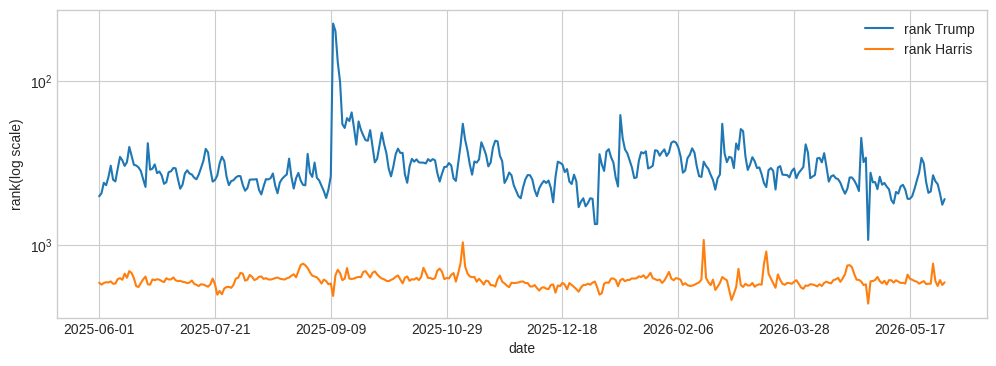

In [31]:
ax=dft_multi.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");

- easy to customize plot using `pandas` and `matplotlib` combo.

In [32]:
# to get the top articles that explain
# the type ranking on a particular day,
# here based on pageview weights.
wiki.term_series(
    "Trump", entity="United States", dates="2025-06-01,2026-06-01",
     ngram_size=1, granularity="daily",
     include="articles"
).df()

,date,counts,rank,freq,articles
0,2025-06-01,46426208,505,0.000173,"[[https://en.wikipedia.org/wiki/Katie_Miller, ..."
1,2025-06-02,46584110,484,0.000177,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
2,2025-06-03,51483109,418,0.000207,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
3,2025-06-04,51027273,432,0.000202,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
4,2025-06-05,55258219,386,0.000223,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
...,...,...,...,...,...
361,2026-05-28,49119374,409,0.000212,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
362,2026-05-29,48654856,426,0.000202,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
363,2026-05-30,38754480,486,0.000180,"[[https://en.wikipedia.org/wiki/Donald_Trump, ..."
364,2026-05-31,37262588,568,0.000160,"[[https://en.wikipedia.org/wiki/Lara_Trump, 31..."


In [ ]:
#try the same plot but with bigrams!

## Batch endpoint

In [38]:
%%time
wiki.term_series("Trump", entity="United States", dates="2025-06-01,2026-06-01").df().head()
wiki.term_series("Harris", entity="United States", dates="2025-06-01,2026-06-01").df().head()
wiki.term_series("Vance", entity="United States", dates="2025-06-01,2026-06-01").df().head()
wiki.term_series("Walz", entity="United States", dates="2025-06-01,2026-06-01").df().head()

CPU times: user 22.8 ms, sys: 960 µs, total: 23.8 ms
Wall time: 323 ms


,date,counts,rank,freq
0,2025-06-01,632108,23550,0.000002
1,2025-06-02,736165,21163,0.000003
2,2025-06-03,778746,19640,0.000003
3,2025-06-04,704583,21123,0.000003
4,2025-06-05,601401,23167,0.000002


In [39]:
# scales better
%time wiki.term_series_batch(["Trump", "Harris", "Vance", "Walz"], entity="United States", dates="2025-06-01,2026-06-01").df().head()

CPU times: user 9.65 ms, sys: 776 µs, total: 10.4 ms
Wall time: 170 ms


,date,counts,rank,freq,type
0,2025-06-01,46426208,505,0.000173,Trump
1,2025-06-02,46584110,484,0.000177,Trump
2,2025-06-03,51483109,418,0.000207,Trump
3,2025-06-04,51027273,432,0.000202,Trump
4,2025-06-05,55258219,386,0.000223,Trump


## Domain objects & dynamic routes

In [40]:
# one-argument scoping works when a domain has a single dataset;
# displaying it lists the endpoints (mirrors GET /{domain})
tw = client.dataset("twitter")
tw

Domain 'twitter' — endpoints:
datasets: ['ngrams'] — client.dataset('twitter', <id>) for metadata

In [41]:
# multi-dataset domains ask you to choose — errors carry the fix
try:
    client.dataset("wikimedia").availability
except ValueError as e:
    print(e)

This is dataset-specific and domain 'wikimedia' has 6 registered datasets — use client.dataset('wikimedia', <id>) with id in ['ngrams', 'ngrams-articles', 'ngrams-sparklines', 'precomputed_rtd', 'revisions', 'semantic-timeseries'].


In [42]:
# any route is callable by its guessable name (underscores map to dashes)
wiki.revisions(limit=2)["articles"]

[{'identifier': 81858235,
  'name': 'Deaths in 2026',
  'revision_count': 3481,
  'first_edit': '2026-01-02T16:18:43Z',
  'last_edit': '2026-03-06T23:46:27Z'},
 {'identifier': 82533582,
  'name': '2026 Israeli–United States strikes on Iran',
  'revision_count': 3071,
  'first_edit': '2026-02-28T06:24:01Z',
  'last_edit': '2026-03-07T00:00:43Z'}]

## The escape hatch & platform status

In [43]:
# routes without a dedicated method are one .get() away
client.get("/open-academic-analytics/authors")[:1]

[{'ego_display_name': 'Abigail Crocker',
  'current_age': 20,
  'last_pub_year': 2024,
  'has_research_group': False}]

In [44]:
# component versions and dataset health
client.version(), client.health.status()["summary"]

({'api': '1.0.0',
  'schemas': '0.3.1',
  'duckdb': '1.5.0',
  'allotax': '0.3.2',
  'wordshift': '0.1.1'},
 {'total': 29, 'healthy': 28, 'degraded': 0, 'unhealthy': 1})

## Where next?

The [multi-platform notebook](https://colab.research.google.com/drive/1I-PPb4kLXbVWApx-jn77pZOU0NVfIweV?usp=sharing) is nice to learn a bit more about our API.